In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [2]:
df.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [3]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# Load the metadata CSV file
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
#df = df.drop(['Gender', 'Weight'], axis=1)

# Preview the data
print(df.head())

# Separate features and target
X = df.loc[:, df.columns != 'NObeyesdad']
y = df['NObeyesdad']

# Convert categorical features to dummy variables (if any)
X = pd.get_dummies(X)

# Encode target variable if needed
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)  # Shows the mapping

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


# Create an XGBClassifier (XGBoost handles NaNs by default)
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
)

# Train the model (XGBoost automatically handles np.nan values)
xgb_model.fit(X_train, y_train)

# Predict on the test data
y_pred = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optionally, perform 5-fold cross-validation to assess model performance
cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5)
print("5-Fold Cross Validation Accuracy:", cv_scores.mean())


   Gender  Age  Height  Weight family_history_with_overweight FAVC  FCVC  NCP  \
0  Female   21    1.62    64.0                            yes   no   2.0  3.0   
1  Female   21    1.52    56.0                            yes   no   3.0  3.0   
2    Male   23    1.80    77.0                            yes   no   2.0  3.0   
3    Male   27    1.80    87.0                             no   no   3.0  3.0   
4    Male   22    1.78    89.8                             no   no   2.0  1.0   

        CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0  Sometimes    no   2.0   no  0.0  1.0          no  Public_Transportation   
1  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes  Public_Transportation   
2  Sometimes    no   2.0   no  2.0  1.0  Frequently  Public_Transportation   
3  Sometimes    no   2.0   no  2.0  0.0  Frequently                Walking   
4  Sometimes    no   2.0   no  0.0  0.0   Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Wei

/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Test Accuracy: 0.9550827423167849

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94        54
           1       0.85      0.97      0.90        58
           2       0.96      0.97      0.96        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.96      0.90      0.93        58
           6       0.97      0.97      0.97        58

    accuracy                           0.96       423
   macro avg       0.96      0.95      0.95       423
weighted avg       0.96      0.96      0.96       423



/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:24:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:24:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [14:24:38] WARNING: /Users/runner/

5-Fold Cross Validation Accuracy: 0.9555320269346689


In [5]:
# Retrieve feature importances
importances = xgb_model.feature_importances_

# Create a DataFrame to display feature importances sorted by value
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
                               feature  importance
8                        Gender_Female    0.206213
17                             CAEC_no    0.182409
2                               Weight    0.109153
3                                 FCVC    0.076905
15                     CAEC_Frequently    0.054548
1                               Height    0.040684
12                             FAVC_no    0.038934
5                                 CH2O    0.036419
30                      MTRANS_Walking    0.032584
25                             CALC_no    0.029689
24                      CALC_Sometimes    0.028770
4                                  NCP    0.021443
14                         CAEC_Always    0.020286
0                                  Age    0.018902
6                                  FAF    0.016254
20                              SCC_no    0.015928
7                                  TUE    0.013824
26                   MTRANS_Automobile    0.012757
16        

In [6]:
X_train.columns

Index(['Age', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes',
       'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no',
       'SMOKE_no', 'SMOKE_yes', 'SCC_no', 'SCC_yes', 'CALC_Always',
       'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile',
       'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation',
       'MTRANS_Walking'],
      dtype='object')

Confusion Matrix:
[[46  3  1  1  1  1  1]
 [ 5 45  5  0  0  2  1]
 [ 0  3 61  1  0  2  3]
 [ 0  2  0 58  0  0  0]
 [ 0  1  0  0 64  0  0]
 [ 1  6  6  0  0 44  1]
 [ 0  5  4  0  0  0 49]]


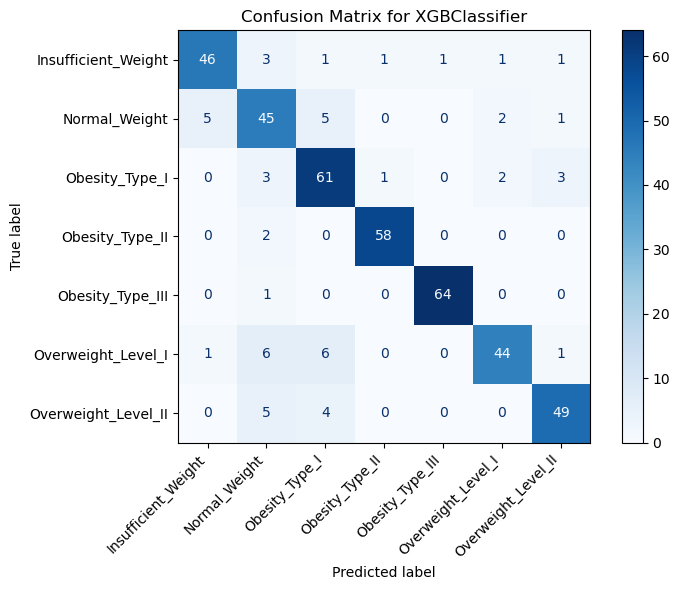

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Create a figure and axis to adjust size and layout
fig, ax = plt.subplots(figsize=(8, 6))

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for XGBClassifier")

# Rotate x-axis labels to 45 degrees to prevent overlap
plt.xticks(rotation=45)

# Align the tick labels to the right (instead of the center)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()  # Adjust layout to ensure everything fits
plt.show()

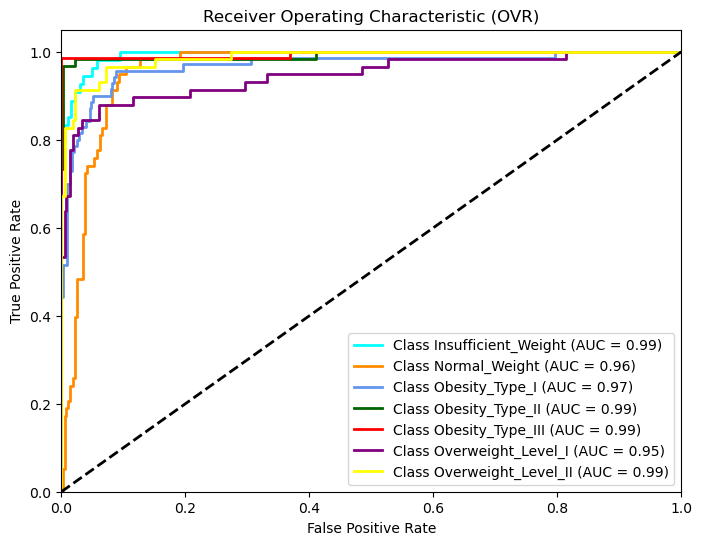

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get the predicted probabilities for each class
y_proba = xgb_model.predict_proba(X_test)

# If binary classification, plot a single ROC curve for class 1
if len(np.unique(y_test)) == 2:
    # For binary, use the probability of class 1
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:0.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (OVR)')
    plt.legend(loc="lower right")
    plt.show()

else:
    # For multi-class, first binarize the output
    classes = np.unique(y_test)
    y_test_binarized = label_binarize(y_test, classes=classes)
    n_classes = y_test_binarized.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'red', 'purple', 'yellow']

    plt.figure(figsize=(8, 6))
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], lw=2,
                 label=f'Class {le.classes_[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (OVR)')
    plt.legend(loc="lower right")
    plt.show()


In [9]:
print(le.classes_)

['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [10]:
import numpy as np
from sklearn.metrics import accuracy_score

# Number of Monte Carlo simulation iterations
n_iterations = 100

# List to store accuracy for each iteration
accuracy_list = []

# Loop over iterations
for i in range(n_iterations):
    # Create a noise matrix with the same shape as X_test,
    # where each element is drawn uniformly from [0.9, 1.1]
    noise = np.random.uniform(0.9, 1.1, X_test.shape)
    
    # Perturb the test set: multiply elementwise
    X_test_perturbed = X_test * noise
    # Predict using the trained xgboost model
    y_pred = xgb_model.predict(X_test_perturbed)
    
    # Compute accuracy on perturbed test set
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

# Convert accuracy list to numpy array for statistics
accuracy_array = np.array(accuracy_list)

print("Monte Carlo Sensitivity Analysis (±10% perturbation):")
print(f"  Mean Accuracy: {accuracy_array.mean():.4f}")
print(f"  Std Dev Accuracy: {accuracy_array.std():.4f}")
print(f"  Min Accuracy: {accuracy_array.min():.4f}")
print(f"  Max Accuracy: {accuracy_array.max():.4f}")


Monte Carlo Sensitivity Analysis (±10% perturbation):
  Mean Accuracy: 0.4443
  Std Dev Accuracy: 0.0199
  Min Accuracy: 0.3972
  Max Accuracy: 0.4965


In [12]:
X_test_perturbed

,Age,Height,FCVC,NCP,CH2O,FAF,TUE,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
572,17.982821,1.859257,2.985610,4.072460,1.141907,1.974367,0.931256,1.073352,0.000000,0.000000,...,0.0,0.0,0.0,1.082214,0.000000,0.000000,0.0,0.0,0.901649,0.0
370,19.130485,1.637900,2.191144,3.021228,0.972466,1.040709,1.022438,0.920990,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.991350,0.000000,0.0,0.0,1.056799,0.0
1002,21.670152,1.600684,1.975015,2.749572,2.675282,0.000000,0.336475,0.000000,1.040438,0.000000,...,0.0,0.0,0.0,1.075859,0.000000,0.000000,0.0,0.0,1.045784,0.0
1837,20.973251,1.648860,3.267590,3.027954,2.868526,0.477992,0.681766,0.000000,1.017608,0.000000,...,0.0,0.0,0.0,0.929885,0.000000,0.000000,0.0,0.0,0.920938,0.0
1724,30.306015,1.677856,2.423799,2.543588,1.033033,2.186536,0.000000,0.000000,1.061210,0.000000,...,0.0,0.0,0.0,0.000000,1.078386,0.000000,0.0,0.0,1.001244,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548,29.864747,1.617686,2.696820,3.243751,2.606045,0.626464,1.739280,0.000000,1.062863,0.000000,...,0.0,0.0,0.0,1.028959,0.000000,0.941868,0.0,0.0,0.000000,0.0
1161,16.906693,1.598808,2.531572,2.425861,2.042201,1.472799,0.799072,0.000000,1.062339,0.980388,...,0.0,0.0,0.0,0.000000,1.022395,0.000000,0.0,0.0,1.071075,0.0
1537,32.035965,1.715472,3.180217,4.169648,0.955614,1.991392,0.000000,0.000000,0.903829,0.000000,...,0.0,0.0,0.0,0.000000,0.915736,0.000000,0.0,0.0,0.915998,0.0
497,21.701875,1.542141,2.064913,2.780399,1.941040,0.952172,1.050382,0.911835,0.000000,1.044443,...,0.0,0.0,0.0,0.917797,0.000000,0.000000,0.0,0.0,1.089471,0.0


In [13]:
X_test

,Age,Height,FCVC,NCP,CH2O,FAF,TUE,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
572,19,1.77,3.00,3.73,1.19,2.00,1.000,True,False,False,...,False,False,False,True,False,False,False,False,True,False
370,19,1.80,2.00,3.00,1.00,1.00,1.000,True,False,False,...,False,False,False,False,True,False,False,False,True,False
1002,24,1.70,2.00,3.00,2.88,0.00,0.322,False,True,False,...,False,False,False,True,False,False,False,False,True,False
1837,21,1.81,3.00,3.00,2.64,0.48,0.735,False,True,False,...,False,False,False,True,False,False,False,False,True,False
1724,33,1.70,2.68,2.42,1.00,1.99,0.000,False,True,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1548,31,1.77,2.96,3.00,2.38,0.61,1.875,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1161,18,1.66,2.49,2.27,1.99,1.45,0.865,False,True,True,...,False,False,False,False,True,False,False,False,True,False
1537,31,1.67,2.91,3.99,1.00,2.00,0.000,False,True,False,...,False,False,False,False,True,False,False,False,True,False
497,20,1.56,2.00,3.00,2.00,1.00,1.000,True,False,True,...,False,False,False,True,False,False,False,False,True,False
